In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from math import pi
import re
import json
from pathlib import Path


# Set style for better visualizations
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Configuration:
  Sequence Length: 512
  Batch Size per GPU: 16
  Data Parallel Size: 4
  Tokens per Step: 32768
Successfully loaded stage 0 metrics: 120 records
Successfully loaded stage 1 metrics: 120 records
Successfully loaded stage 2 metrics: 121 records
Successfully loaded stage 3 metrics: 121 records
Stage 0: Loaded 480 microstep records
Stage 1: Loaded 480 microstep records
Stage 2: Loaded 480 microstep records
Stage 3: Loaded 480 microstep records

Total microstep records: 1920

Available columns in df_all: ['stage', 'step', 'loss', 'lr', 'iteration_time_ms', 'fwd_ms', 'bwd_ms', 'step_ms', 'compute_ms', 'comm_ms', 'comm_pct', 'throughput_tps', 'gpu_util', 'temp_c', 'alloc_gb', 'reserved_gb', 'peak_gb']
Available columns in df_micro_all: ['fwd_microstep', 'bwd_microstep', 'bwd_inner_microstep', 'bwd_allreduce_microstep', 'step_microstep', 'real_compute_ms', 'real_comm_ms', 'real_comm_pct', 'total_microstep_time', 'compute_efficiency', 'stage', 'step']

TABLE 1: ZeRO Stage Perfor

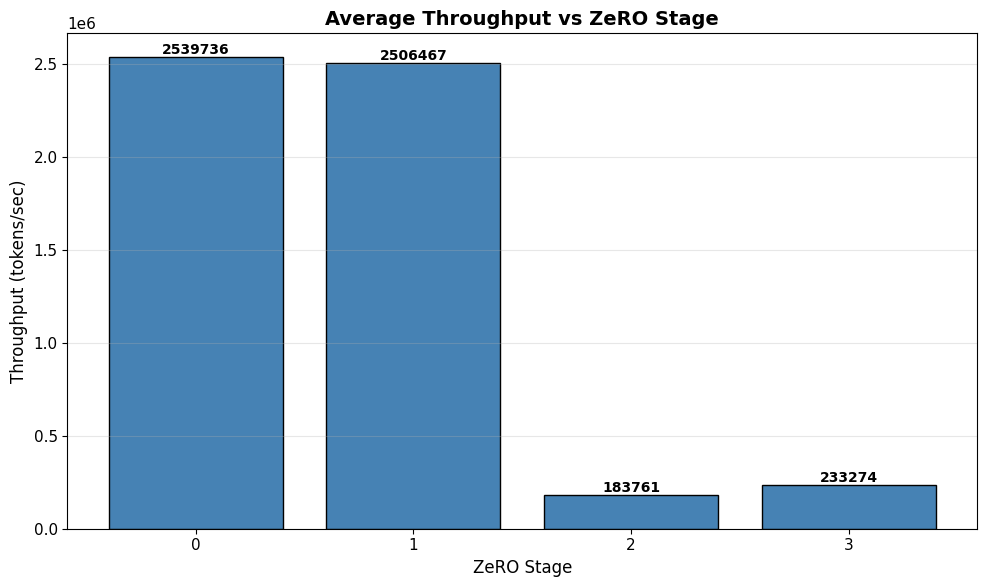

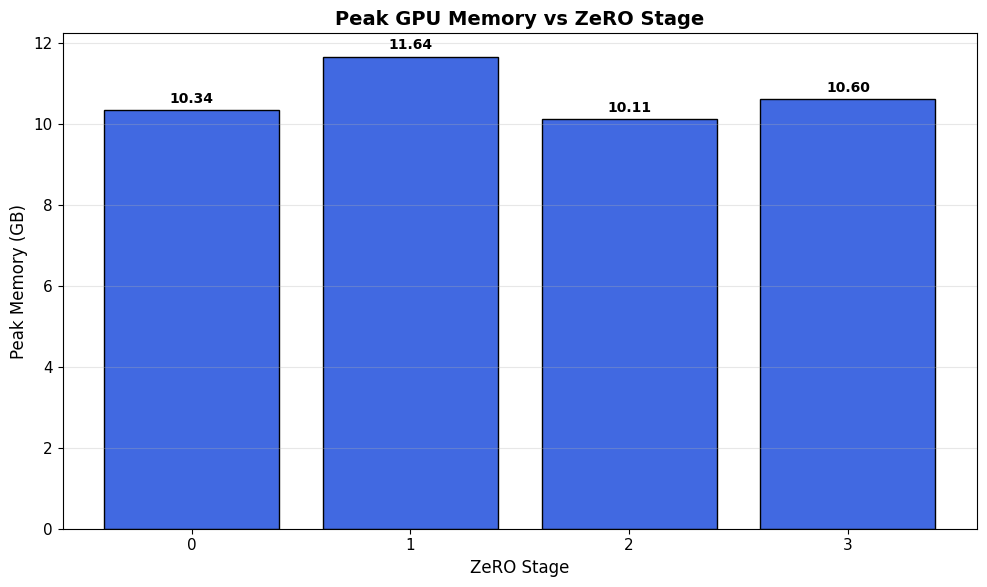

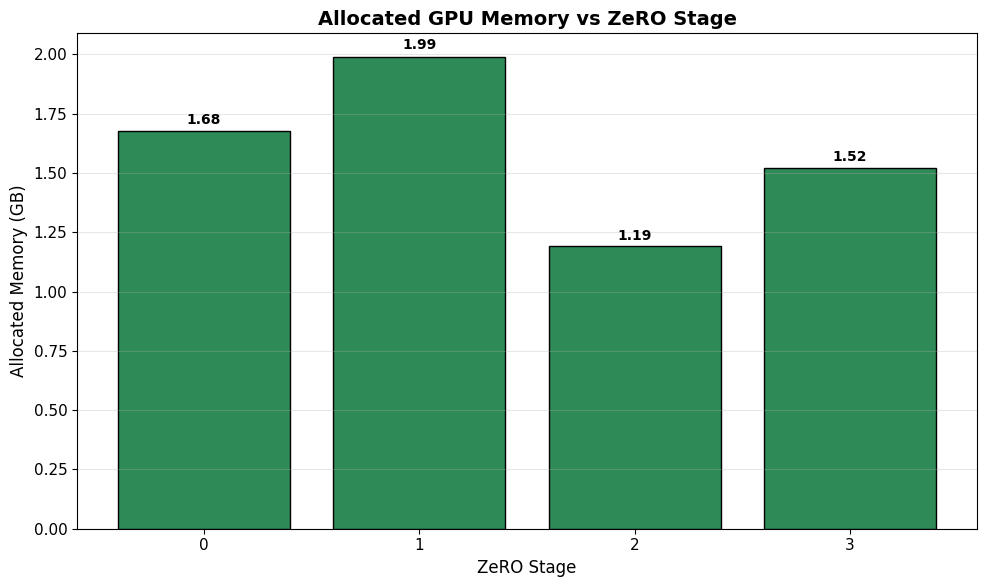

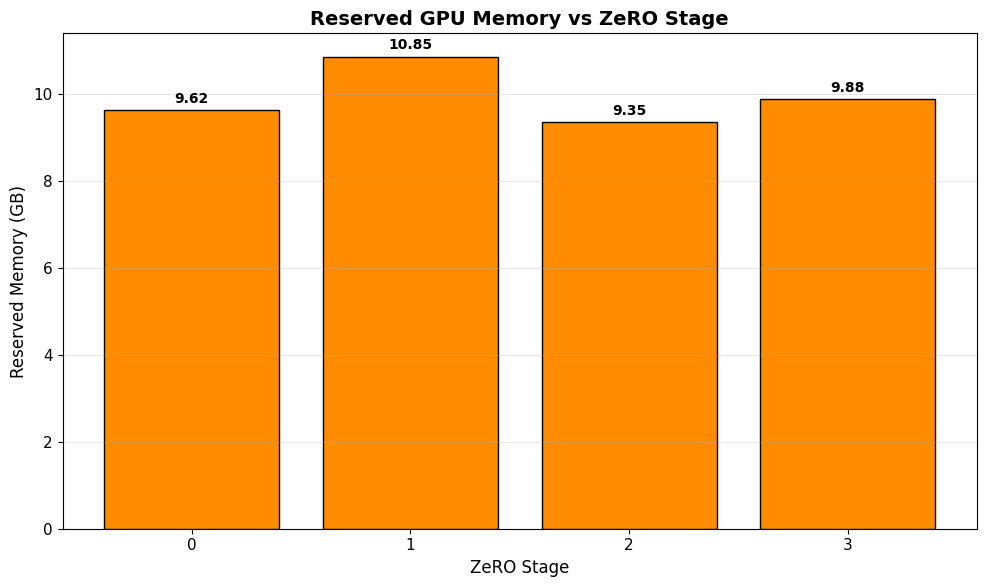

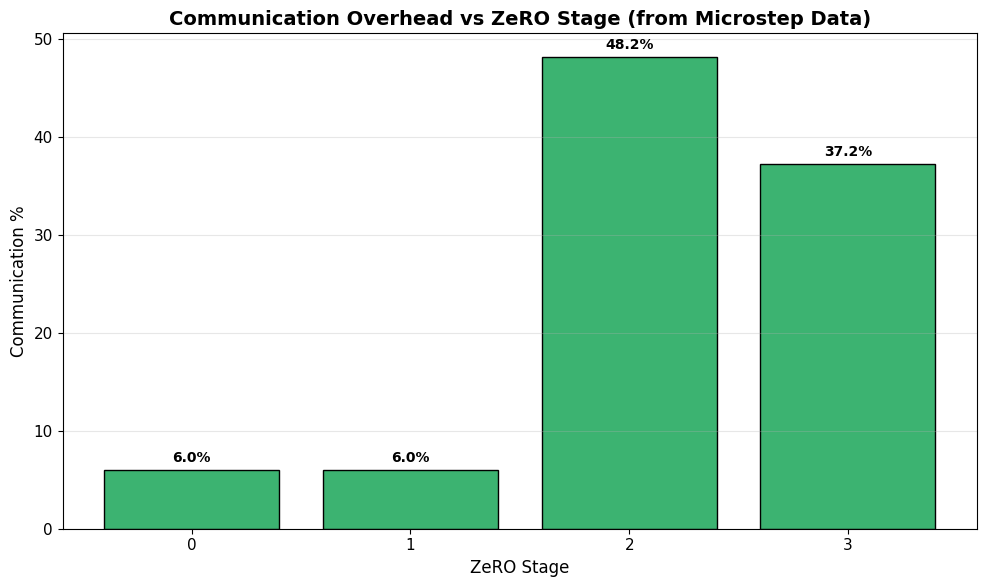

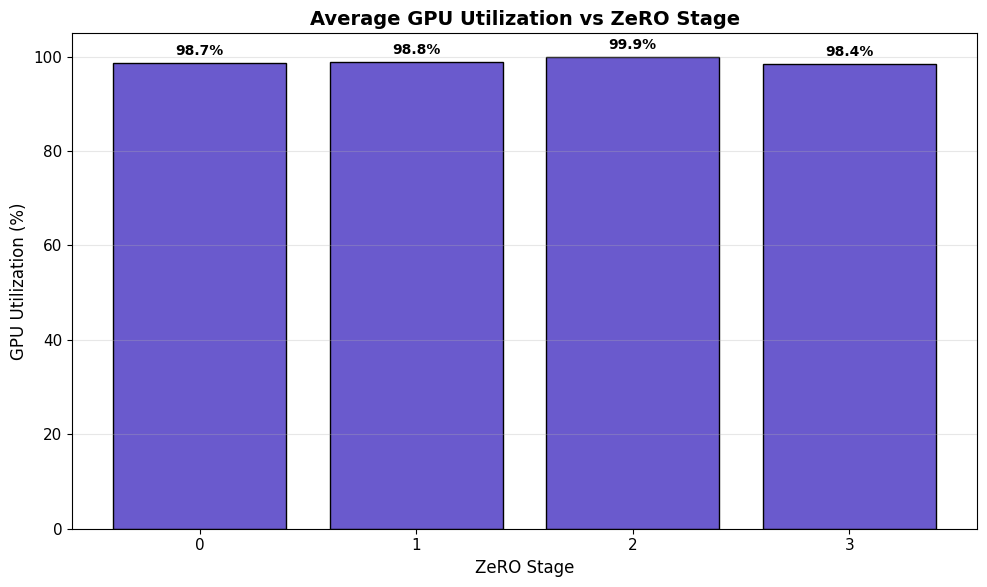

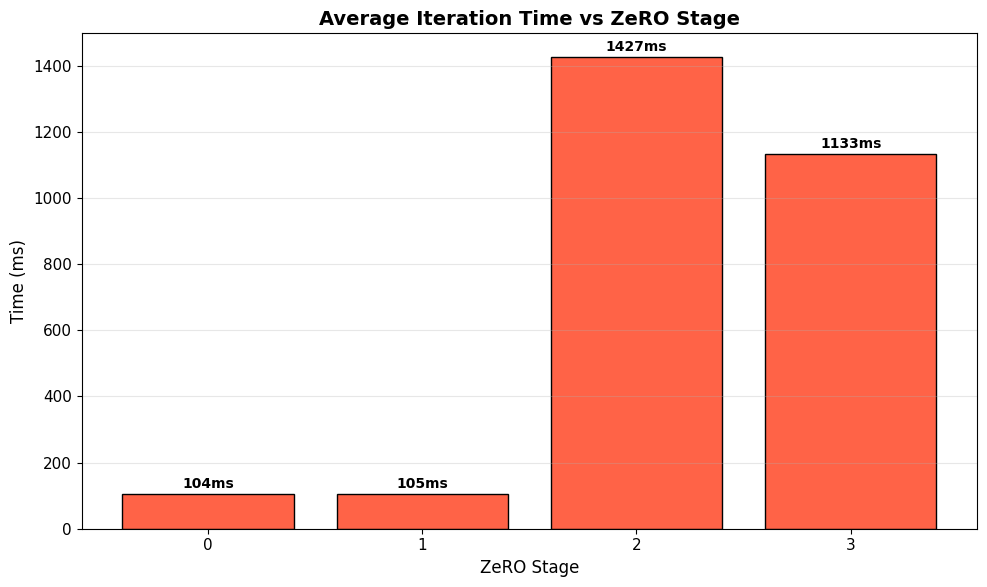

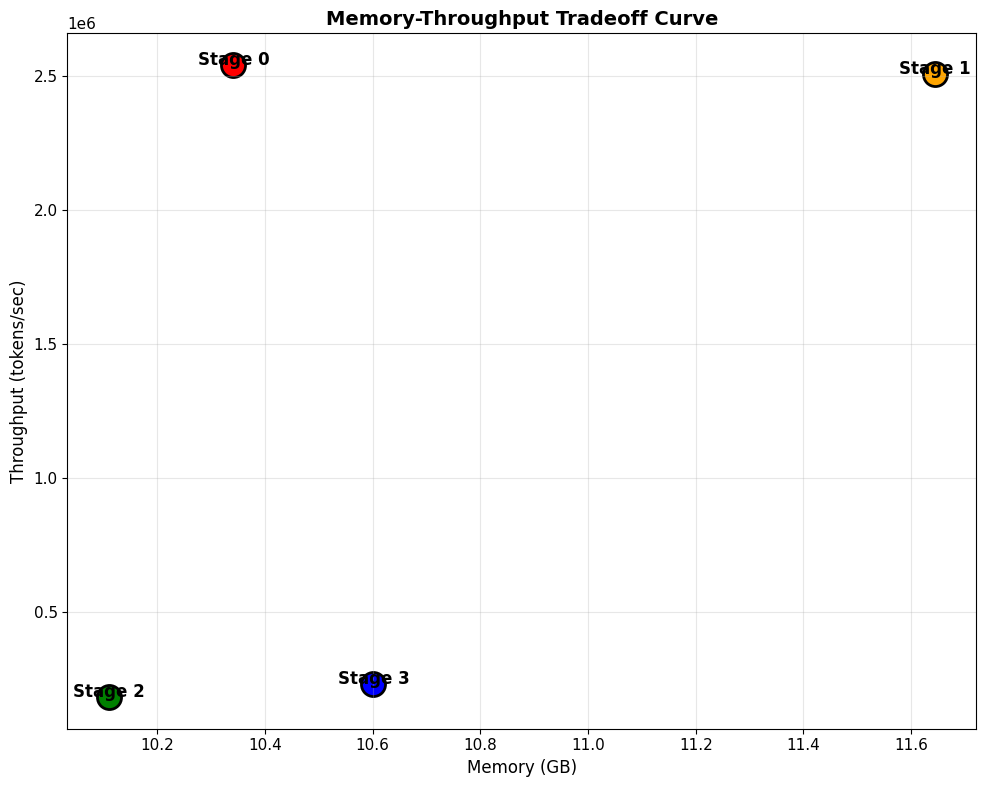

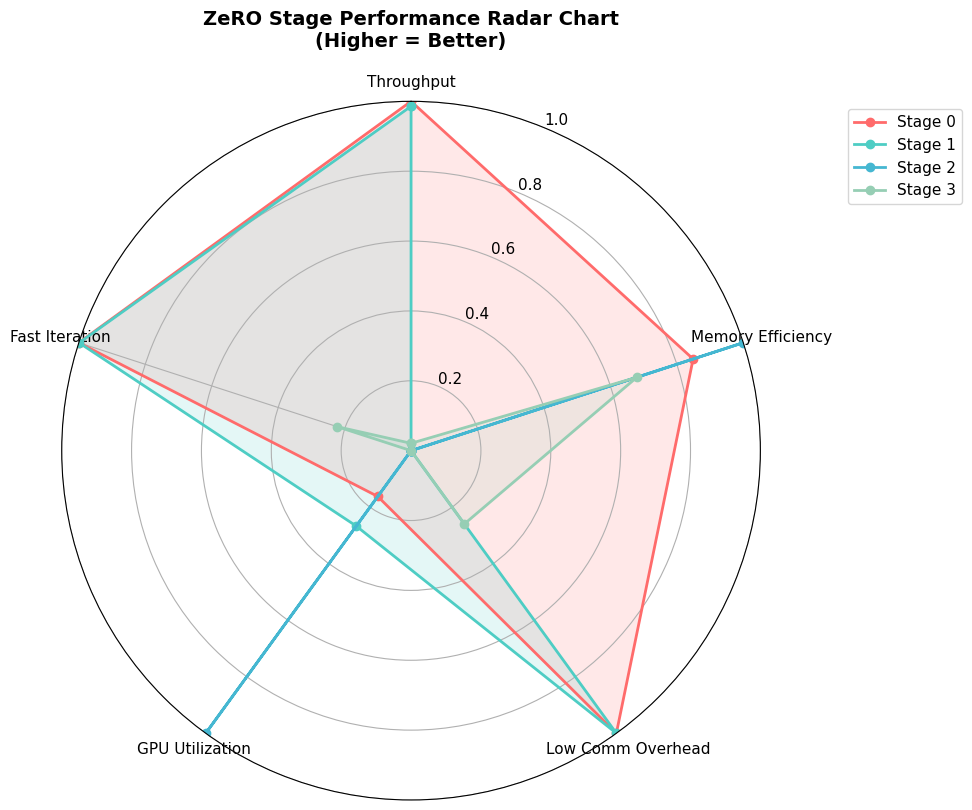


PERFORMANCE SUMMARY TABLE
 stage  iteration_time_ms  throughput_tps  peak_gb  alloc_gb  reserved_gb  gpu_util  compute_ms  comm_ms  comm_pct  fwd_ms   bwd_ms  step_ms  total_time_s  compute_comm_ratio  compute_pct  mfu_pct
     0             103.61      2539736.39    10.34      1.68         9.62     98.66      807.70     0.02      0.00  313.64   494.06   807.76         12.43            38009.46       100.00   100.00
     1             104.83      2506467.00    11.64      1.99        10.85     98.82      817.03     0.02      0.00  317.57   499.46   817.09         12.58            37854.56       100.00   100.00
     2            1426.58       183760.75    10.11      1.19         9.35     99.93    11325.64 10506.37     47.75  307.59 11018.05 21820.27        172.62                1.08        51.88    51.88
     3            1132.74       233273.63    10.60      1.52         9.88     98.41     9020.78  5318.60     37.26 3224.04  5796.74 14330.03        137.06                1.70        62.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# ============================================================================
# CONFIGURATION
# ============================================================================
SEQ_LEN = 512  # Your sequence length
BATCH_SIZE_PER_GPU = 16
DP_SIZE = 4
TOKENS_PER_STEP = BATCH_SIZE_PER_GPU * DP_SIZE * SEQ_LEN

print(f"Configuration:")
print(f"  Sequence Length: {SEQ_LEN}")
print(f"  Batch Size per GPU: {BATCH_SIZE_PER_GPU}")
print(f"  Data Parallel Size: {DP_SIZE}")
print(f"  Tokens per Step: {TOKENS_PER_STEP}")

# ============================================================================
# DATA EXTRACTION FUNCTION
# ============================================================================
def extract_logs(text):
    fwd_microstep, compute_norm, fwd, optimizer_allgather = [], [], [], []   
    for line in text:
        if "[Rank" in line:
            parts = line.split('|')[1:]
            metrics = {}
            for p in parts:
                if ':' in p:
                    key = p.split(':')[0].strip()
                    try:
                        metrics[key] = float(p.split(':')[1].strip())
                    except ValueError:
                        pass
            
            if metrics:
                if 'fwd_microstep' in metrics:  
                    # Add derived metrics
                    metrics["real_compute_ms"] = (metrics.get("fwd_microstep", 0) + 
                                                 metrics.get("bwd_microstep", 0))
                    metrics["real_comm_ms"] = metrics.get("bwd_allreduce_microstep", 0)
                    total = metrics["real_comm_ms"] + metrics["real_compute_ms"]
                    metrics["real_comm_pct"] = (metrics["real_comm_ms"] / total * 100) if total > 0 else 0
                    metrics["total_microstep_time"] = (metrics.get("fwd_microstep", 0) + 
                                                       metrics.get("bwd_microstep", 0) + 
                                                       metrics.get("bwd_allreduce_microstep", 0) + 
                                                       metrics.get("step_microstep", 0))
                    metrics["compute_efficiency"] = (metrics["real_compute_ms"] / 
                                                     metrics["total_microstep_time"] * 100) if metrics["total_microstep_time"] > 0 else 0
                    fwd_microstep.append(metrics) 
                elif 'compute_norm' in metrics:
                    compute_norm.append(metrics)
                elif 'fwd' in metrics:
                    fwd.append(metrics)
                elif ('optimizer_allgather' in metrics) or ('optimizer_step' in metrics):
                    optimizer_allgather.append(metrics)
                
    return fwd_microstep, compute_norm, fwd, optimizer_allgather

# ============================================================================
# LOAD DATA
# ============================================================================
json_files = {
    0: "../results/stage_0_metrics.json",
    1: "../results/stage_1_metrics.json",
    2: "../results/stage_2_metrics.json",
    3: "../results/stage_3_metrics.json"
}

logs = ['stage_0_0-480.log',
        'stage_1_0-480.log',
        'stage_2_0-480.log',
        'stage_3_0-480.log']

# Load JSON metrics
all_metrics = []
for i in range(0,4):
    try:
        df_temp = pd.read_json(json_files[i])
        df_temp['stage'] = i
        all_metrics.append(df_temp)
        print(f"Successfully loaded stage {i} metrics: {len(df_temp)} records")
    except Exception as e:
        print(f"Error loading stage {i} JSON: {e}")
        all_metrics.append(pd.DataFrame(columns=['stage', 'step', 'iteration_time_ms', 'throughput_tps', 
                                                  'peak_gb', 'alloc_gb', 'reserved_gb', 'gpu_util']))

df_all = pd.concat(all_metrics, ignore_index=True)

# Process microstep logs
micro_all = []
for stage_id in range(0, 4):
    try:
        with open(logs[stage_id]) as f:
            data = f.readlines()
            fwd_microstep, compute_norm, fwd, optimizer_allgather = extract_logs(data)
            df_fwd_microstep = pd.DataFrame(fwd_microstep)
            if not df_fwd_microstep.empty:
                df_fwd_microstep["stage"] = stage_id
                if 'microstep_idx' not in df_fwd_microstep.columns and 'step' not in df_fwd_microstep.columns:
                    df_fwd_microstep['step'] = range(len(df_fwd_microstep))
                micro_all.append(df_fwd_microstep)
                print(f"Stage {stage_id}: Loaded {len(df_fwd_microstep)} microstep records")
            else:
                print(f"Stage {stage_id}: No microstep data found")
    except Exception as e:
        print(f"Error loading stage {stage_id} log: {e}")

if micro_all:
    df_micro_all = pd.concat(micro_all, ignore_index=True)
    print(f"\nTotal microstep records: {len(df_micro_all)}")
else:
    df_micro_all = pd.DataFrame()
    print("WARNING: No microstep data loaded!")

# ============================================================================
# MERGE AND PROCESS DATA
# ============================================================================
print("\nAvailable columns in df_all:", df_all.columns.tolist())
if not df_micro_all.empty:
    print("Available columns in df_micro_all:", df_micro_all.columns.tolist())

if not df_micro_all.empty:
    micro_per_step = 4
    df_micro_sampled = df_micro_all.iloc[::micro_per_step].copy() if len(df_micro_all) > micro_per_step else df_micro_all.copy()
    
    # Map columns based on what's actually available
    rename_dict = {}
    if 'real_compute_ms' in df_micro_sampled.columns:
        rename_dict['real_compute_ms'] = 'compute_ms'
    if 'real_comm_ms' in df_micro_sampled.columns:
        rename_dict['real_comm_ms'] = 'comm_ms'
    if 'total_microstep_time' in df_micro_sampled.columns:
        rename_dict['total_microstep_time'] = 'step_ms'
    if 'real_comm_pct' in df_micro_sampled.columns:
        rename_dict['real_comm_pct'] = 'comm_pct'
    if 'fwd_microstep' in df_micro_sampled.columns:
        rename_dict['fwd_microstep'] = 'fwd_ms'
    if 'bwd_microstep' in df_micro_sampled.columns:
        rename_dict['bwd_microstep'] = 'bwd_ms'
    
    df_micro_sampled = df_micro_sampled.rename(columns=rename_dict)
    
    # Add derived columns
    if 'compute_ms' in df_micro_sampled.columns and 'comm_ms' in df_micro_sampled.columns:
        df_micro_sampled['compute_comm_ratio'] = (
            df_micro_sampled['compute_ms'] / df_micro_sampled['comm_ms'].replace(0, np.nan)
        )
        df_micro_sampled['compute_pct'] = (
            df_micro_sampled['compute_ms'] /
            (df_micro_sampled['compute_ms'] + df_micro_sampled['comm_ms'])
        ) * 100
    
    # Merge with main dataframe
    micro_cols = [c for c in ['compute_comm_ratio', 'compute_pct', 'comm_ms', 'compute_ms', 
                               'step_ms', 'comm_pct', 'fwd_ms', 'bwd_ms', 'compute_efficiency'] 
                  if c in df_micro_sampled.columns]
    
    if micro_cols:
        df_all_updated = df_all.merge(
            df_micro_sampled[['stage', 'step'] + micro_cols],
            on=['stage', 'step'],
            how='left',
            suffixes=('', '_micro')
        )
        
        # Update columns with microstep data where available
        for col in ['comm_ms', 'compute_ms', 'step_ms', 'comm_pct', 'fwd_ms', 'bwd_ms']:
            if f"{col}_micro" in df_all_updated.columns and col in df_all_updated.columns:
                df_all_updated[col] = df_all_updated[f"{col}_micro"].fillna(df_all_updated[col])
                if f"{col}_micro" in df_all_updated.columns:
                    df_all_updated.drop(columns=[f"{col}_micro"], inplace=True)
        
        df_all = df_all_updated

# ============================================================================
# CREATE SUMMARY STATISTICS
# ============================================================================
agg_dict = {
    "iteration_time_ms": "mean",
    "throughput_tps": "mean",
    "peak_gb": "max",
    "alloc_gb": "mean",
    "reserved_gb": "mean",
    "gpu_util": "mean",
}

optional_cols = ["compute_ms", "comm_ms", "comm_pct", "fwd_ms", "bwd_ms", "step_ms"]
for col in optional_cols:
    if col in df_all.columns:
        agg_dict[col] = "mean"

summary = df_all.groupby("stage").agg(agg_dict).reset_index()

# Add computed columns
summary["total_time_s"] = df_all.groupby("stage")["iteration_time_ms"].sum().values / 1000

if "compute_ms" in summary.columns and "comm_ms" in summary.columns:
    summary["compute_comm_ratio"] = summary["compute_ms"] / summary["comm_ms"].replace(0, np.nan)
    summary["compute_pct"] = (
        summary["compute_ms"] / (summary["compute_ms"] + summary["comm_ms"])
    ) * 100
    summary["mfu_pct"] = summary["compute_pct"]

# Microstep communication summary
if not df_micro_all.empty and 'real_comm_pct' in df_micro_all.columns:
    micro_comm_summary = df_micro_all.groupby("stage").agg({
        "real_comm_pct": "mean"
    }).reset_index()
    micro_comm_summary.columns = ["stage", "comm_pct_from_microstep"]
else:
    micro_comm_summary = pd.DataFrame({"stage": [0,1,2,3], "comm_pct_from_microstep": [0,0,0,0]})

# ============================================================================
# TABLE 1: ZeRO Stage Performance Comparison
# ============================================================================
print("\n" + "="*120)
print("TABLE 1: ZeRO Stage Performance Comparison")
print("="*120)

table1_cols = ["stage", "total_time_s", "iteration_time_ms", "throughput_tps",
               "peak_gb", "alloc_gb", "gpu_util"]
for col in ["compute_ms", "comm_ms", "comm_pct", "compute_comm_ratio", "mfu_pct"]:
    if col in summary.columns:
        table1_cols.append(col)

table1 = summary[table1_cols].copy()
table1_display = table1.round(2)
print(table1_display.to_string(index=False))

# ============================================================================
# TABLE 2: Memory Scaling Analysis
# ============================================================================
print("\n" + "="*120)
print("TABLE 2: Memory Scaling Analysis")
print("="*120)

if not summary.empty and 0 in summary['stage'].values:
    baseline_memory = summary[summary["stage"] == 0]["peak_gb"].values[0] if len(summary[summary["stage"] == 0]["peak_gb"].values) > 0 else 0
    
    table2 = summary[["stage", "peak_gb"]].copy()
    table2["model_params_m"] = [51.21, 51.21, 51.21, 26.05]  # From profiler output
    if baseline_memory > 0:
        table2["memory_reduction_pct"] = ((baseline_memory - table2["peak_gb"]) / baseline_memory) * 100
    else:
        table2["memory_reduction_pct"] = 0
    
    table2.columns = ["ZeRO Stage", "Peak VRAM (GB)", "Model Size (M params)", "Memory Reduction (%)"]
    print(table2.round(2).to_string(index=False))

# ============================================================================
# TABLE 3: Communication Analysis (from Microstep Data)
# ============================================================================
print("\n" + "="*120)
print("TABLE 3: Communication Analysis by ZeRO Stage (from Microstep Data)")
print("="*120)

if not df_micro_all.empty:
    micro_agg = {}
    for col in ['fwd_microstep', 'bwd_microstep', 'bwd_allreduce_microstep', 
                'step_microstep', 'real_comm_ms', 'real_comm_pct', 
                'compute_efficiency', 'total_microstep_time']:
        if col in df_micro_all.columns:
            micro_agg[col] = "mean"
    
    if micro_agg:
        micro_summary = df_micro_all.groupby("stage").agg(micro_agg).reset_index()
        
        table3_cols = ["stage", "fwd_microstep", "bwd_microstep", "bwd_allreduce_microstep",
                      "step_microstep", "real_comm_ms", "real_comm_pct", "compute_efficiency"]
        table3_cols = [c for c in table3_cols if c in micro_summary.columns]
        
        table3 = micro_summary[table3_cols].copy()
        table3.columns = ["ZeRO Stage", "FWD (ms)", "BWD (ms)", "AllReduce (ms)",
                         "Step (ms)", "Total Comm (ms)", "Comm %", "Compute Efficiency (%)"]
        print(table3.round(2).to_string(index=False))
    else:
        print("No microstep data available for table 3")
else:
    print("No microstep data available")

# ============================================================================
# TABLE 4: Efficiency Metrics
# ============================================================================
print("\n" + "="*120)
print("TABLE 4: Efficiency Metrics")
print("="*120)

if 'throughput_tps' in summary.columns and 'gpu_util' in summary.columns:
    table4 = summary[["stage", "throughput_tps", "gpu_util"]].copy()
    if 'mfu_pct' in summary.columns:
        table4["mfu_pct"] = summary["mfu_pct"]
    else:
        table4["mfu_pct"] = 0
    
    table4["tokens_per_step"] = TOKENS_PER_STEP
    table4["efficiency_score"] = (table4["throughput_tps"] * table4["gpu_util"]) / (summary["peak_gb"] + 1e-8)
    
    table4.columns = ["ZeRO Stage", "Tokens/sec", "GPU Util (%)", "MFU (%)", "Tokens/Step", "Efficiency Score"]
    print(table4.round(2).to_string(index=False))

# ============================================================================
# TABLE 5: Forward/Backward Breakdown
# ============================================================================
print("\n" + "="*120)
print("TABLE 5: Forward/Backward Time Breakdown")
print("="*120)

fwd_bwd_cols = ["stage", "iteration_time_ms"]
for col in ['fwd_ms', 'bwd_ms', 'step_ms']:
    if col in summary.columns:
        fwd_bwd_cols.append(col)

if len(fwd_bwd_cols) > 2:
    table5 = summary[fwd_bwd_cols].copy()
    table5["fwd_pct"] = (table5["fwd_ms"] / table5["iteration_time_ms"]) * 100 if 'fwd_ms' in table5.columns else 0
    table5["bwd_pct"] = (table5["bwd_ms"] / table5["iteration_time_ms"]) * 100 if 'bwd_ms' in table5.columns else 0
    table5["step_pct"] = (table5["step_ms"] / table5["iteration_time_ms"]) * 100 if 'step_ms' in table5.columns else 0
    
    table5.columns = ["ZeRO Stage", "Iter Time (ms)", "FWD (ms)", "BWD (ms)", "Step (ms)", "FWD %", "BWD %", "Step %"]
    print(table5.round(2).to_string(index=False))

# ============================================================================
# TABLE 6: Microstep Component Breakdown
# ============================================================================
print("\n" + "="*120)
print("TABLE 6: Microstep Component Breakdown")
print("="*120)

if not df_micro_all.empty and 'micro_summary' in locals():
    micro_breakdown_cols = ["stage", "total_microstep_time", "compute_efficiency"]
    for col in ['fwd_microstep', 'bwd_microstep', 'bwd_allreduce_microstep', 'step_microstep']:
        if col in micro_summary.columns:
            micro_breakdown_cols.append(col)
    
    if len(micro_breakdown_cols) > 3:
        table6 = micro_summary[micro_breakdown_cols].copy()
        
        if 'total_microstep_time' in table6.columns:
            if 'fwd_microstep' in table6.columns:
                table6["fwd_pct"] = (table6["fwd_microstep"] / table6["total_microstep_time"]) * 100
            if 'bwd_microstep' in table6.columns:
                table6["bwd_pct"] = (table6["bwd_microstep"] / table6["total_microstep_time"]) * 100
            if 'bwd_allreduce_microstep' in table6.columns:
                table6["allreduce_pct"] = (table6["bwd_allreduce_microstep"] / table6["total_microstep_time"]) * 100
            if 'step_microstep' in table6.columns:
                table6["step_pct"] = (table6["step_microstep"] / table6["total_microstep_time"]) * 100
        
        cols = ["ZeRO Stage", "Total (ms)", "Compute Eff (%)"]
        if 'fwd_microstep' in table6.columns:
            cols.extend(["FWD (ms)", "FWD %"])
        if 'bwd_microstep' in table6.columns:
            cols.extend(["BWD (ms)", "BWD %"])
        if 'bwd_allreduce_microstep' in table6.columns:
            cols.extend(["AllReduce (ms)", "AllReduce %"])
        if 'step_microstep' in table6.columns:
            cols.extend(["Step (ms)", "Step %"])
        
        table6.columns = cols
        print(table6.round(2).to_string(index=False))

# ============================================================================
# TABLE 7: Communication Overhead Summary
# ============================================================================
print("\n" + "="*120)
print("TABLE 7: Communication Overhead Summary")
print("="*120)

if 'comm_pct' in summary.columns:
    table7 = summary[["stage", "comm_pct"]].copy()
    table7 = table7.merge(micro_comm_summary, on="stage", how="left")
    
    if 'compute_efficiency' in micro_summary.columns if 'micro_summary' in locals() else False:
        table7 = table7.merge(micro_summary[["stage", "compute_efficiency"]], on="stage", how="left")
        table7.columns = ["ZeRO Stage", "Comm % (Main)", "Comm % (Microstep)", "Compute Efficiency (%)"]
    else:
        table7.columns = ["ZeRO Stage", "Comm % (Main)", "Comm % (Microstep)"]
    
    print(table7.round(2).to_string(index=False))

# ============================================================================
# TABLE 8: Performance Comparison (Stage 1-3 vs Stage 0)
# ============================================================================
print("\n" + "="*120)
print("TABLE 8: Performance Improvement/Regression vs Stage 0 (Baseline)")
print("="*120)

if not summary.empty and 0 in summary['stage'].values:
    baseline = summary[summary["stage"] == 0].iloc[0] if len(summary[summary["stage"] == 0]) > 0 else None
    
    if baseline is not None:
        comparison_data = []
        for _, row in summary.iterrows():
            stage = int(row["stage"])
            if stage == 0:
                continue
            
            throughput_change = ((row["throughput_tps"] - baseline["throughput_tps"]) / baseline["throughput_tps"]) * 100 if baseline["throughput_tps"] > 0 else 0
            memory_reduction = ((baseline["peak_gb"] - row["peak_gb"]) / baseline["peak_gb"]) * 100 if baseline["peak_gb"] > 0 else 0
            comm_increase = row.get("comm_pct", 0) - baseline.get("comm_pct", 0)
            mfu_change = ((row.get("mfu_pct", 0) - baseline.get("mfu_pct", 0)) / baseline.get("mfu_pct", 1)) * 100 if baseline.get("mfu_pct", 0) > 0 else 0
            gpu_util_change = row["gpu_util"] - baseline["gpu_util"]
            
            comparison_data.append({
                "ZeRO Stage": stage,
                "Throughput Change (%)": round(throughput_change, 2),
                "Memory Reduction (%)": round(memory_reduction, 2),
                "Comm Increase (pp)": round(comm_increase, 2),
                "MFU Change (%)": round(mfu_change, 2),
                "GPU Util Change (pp)": round(gpu_util_change, 2)
            })
        
        table8 = pd.DataFrame(comparison_data)
        print(table8.to_string(index=False))

# ============================================================================
# EXPORT ALL TABLES TO CSV
# ============================================================================
table1.to_csv("table1_performance_comparison.csv", index=False)
table2.to_csv("table2_memory_scaling.csv", index=False)
if not df_micro_all.empty and 'micro_summary' in locals():
    table3.to_csv("table3_communication_analysis.csv", index=False)
table4.to_csv("table4_efficiency_metrics.csv", index=False)
if 'table5' in locals():
    table5.to_csv("table5_fwd_bwd_breakdown.csv", index=False)
if 'table6' in locals():
    table6.to_csv("table6_microstep_breakdown.csv", index=False)
if 'table7' in locals():
    table7.to_csv("table7_communication_summary.csv", index=False)
if 'table8' in locals():
    table8.to_csv("table8_performance_comparison_vs_baseline.csv", index=False)

print("\n" + "="*120)
print("All 8 tables exported to CSV files successfully!")
print("="*120)

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

# Plot 1: Throughput Bar Chart
if 'throughput_tps' in summary.columns:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary["stage"], summary["throughput_tps"], color='steelblue', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("Throughput (tokens/sec)", fontsize=12)
    plt.title("Average Throughput vs ZeRO Stage", fontsize=14, fontweight='bold')
    plt.xticks(summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, summary["throughput_tps"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('01_throughput_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot 2: Memory Bar Charts
def plot_memory_bar(summary, column, ylabel, title, filename, color):
    if column in summary.columns:
        plt.figure(figsize=(10, 6))
        bars = plt.bar(summary["stage"], summary[column], color=color, edgecolor='black')
        plt.xlabel("ZeRO Stage", fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xticks(summary["stage"])
        plt.grid(True, alpha=0.3, axis='y')
        
        for bar, val in zip(bars, summary[column]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        plt.show()

plot_memory_bar(summary, "peak_gb", "Peak Memory (GB)", 
                "Peak GPU Memory vs ZeRO Stage", "02a_peak_memory_bar.png", color='royalblue')
plot_memory_bar(summary, "alloc_gb", "Allocated Memory (GB)", 
                "Allocated GPU Memory vs ZeRO Stage", "02b_alloc_memory_bar.png", color='seagreen')
plot_memory_bar(summary, "reserved_gb", "Reserved Memory (GB)", 
                "Reserved GPU Memory vs ZeRO Stage", "02c_reserved_memory_bar.png", color='darkorange')

# Plot 3: Communication Overhead Bar Chart
if not micro_comm_summary.empty:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(micro_comm_summary["stage"], micro_comm_summary["comm_pct_from_microstep"], 
                   color='mediumseagreen', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("Communication %", fontsize=12)
    plt.title("Communication Overhead vs ZeRO Stage (from Microstep Data)", fontsize=14, fontweight='bold')
    plt.xticks(micro_comm_summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, micro_comm_summary["comm_pct_from_microstep"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('03_comm_overhead_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot 4: GPU Utilization Bar Chart
if 'gpu_util' in summary.columns:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary["stage"], summary["gpu_util"], color='slateblue', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("GPU Utilization (%)", fontsize=12)
    plt.title("Average GPU Utilization vs ZeRO Stage", fontsize=14, fontweight='bold')
    plt.xticks(summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, summary["gpu_util"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('04_gpu_util_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot 5: Iteration Time Bar Chart
if 'iteration_time_ms' in summary.columns:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary["stage"], summary["iteration_time_ms"], color='tomato', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("Time (ms)", fontsize=12)
    plt.title("Average Iteration Time vs ZeRO Stage", fontsize=14, fontweight='bold')
    plt.xticks(summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, summary["iteration_time_ms"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}ms', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('05_iteration_time_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot 6: Memory vs Throughput Tradeoff
if 'peak_gb' in summary.columns and 'throughput_tps' in summary.columns:
    plt.figure(figsize=(10, 8))
    colors = ['red', 'orange', 'green', 'blue']
    for i, row in summary.iterrows():
        plt.scatter(row["peak_gb"], row["throughput_tps"], s=300, 
                   c=[colors[i]], edgecolor='black', linewidth=2)
        plt.text(row["peak_gb"], row["throughput_tps"] + 15, f"Stage {int(row['stage'])}", 
                 ha='center', fontweight='bold', fontsize=12)
    
    plt.xlabel("Memory (GB)", fontsize=12)
    plt.ylabel("Throughput (tokens/sec)", fontsize=12)
    plt.title("Memory-Throughput Tradeoff Curve", fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('06_memory_throughput_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()



# Plot 8: Radar Chart
if all(c in summary.columns for c in ['throughput_tps', 'peak_gb', 'gpu_util', 'iteration_time_ms']):
    metrics_for_radar = ['throughput_tps', 'peak_gb', 'gpu_util', 'iteration_time_ms']
    summary_norm = summary.copy()
    summary_norm = summary_norm.merge(micro_comm_summary, on="stage", how="left")
    
    for metric in metrics_for_radar:
        if metric in ['throughput_tps', 'gpu_util']:
            summary_norm[f'{metric}_norm'] = (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())
        else:
            summary_norm[f'{metric}_norm'] = 1 - (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())
    
    if 'comm_pct_from_microstep' in summary_norm.columns:
        summary_norm['comm_pct_norm'] = 1 - (summary_norm['comm_pct_from_microstep'] - summary_norm['comm_pct_from_microstep'].min()) / (summary_norm['comm_pct_from_microstep'].max() - summary_norm['comm_pct_from_microstep'].min())
    
    categories = ['Throughput', 'Memory Efficiency', 'Low Comm Overhead', 'GPU Utilization', 'Fast Iteration']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, projection='polar')
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    for idx, stage in enumerate(summary_norm['stage']):
        values = [
            summary_norm.loc[idx, 'throughput_tps_norm'],
            summary_norm.loc[idx, 'peak_gb_norm'],
            summary_norm.loc[idx, 'comm_pct_norm'] if 'comm_pct_norm' in summary_norm.columns else 0.5,
            summary_norm.loc[idx, 'gpu_util_norm'],
            summary_norm.loc[idx, 'iteration_time_ms_norm']
        ]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f'Stage {int(stage)}', color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_ylim(0, 1)
    ax.set_title('ZeRO Stage Performance Radar Chart\n(Higher = Better)', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('08_radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("PERFORMANCE SUMMARY TABLE")
print("="*80)
print(summary.round(2).to_string(index=False))

print("\n" + "="*80)
print("COMMUNICATION PERCENTAGE (FROM MICROSTEP DATA)")
print("="*80)
print(micro_comm_summary.round(2).to_string(index=False))

print("\n" + "="*80)
print("TRADEOFF ANALYSIS")
print("="*80)

for _, row in summary.iterrows():
    stage = int(row['stage'])
    print(f"\nZeRO Stage {stage}:")
    if 'throughput_tps' in row:
        print(f"  • Throughput: {row['throughput_tps']:.1f} tokens/sec")
    if 'peak_gb' in row:
        print(f"  • Memory: {row['peak_gb']:.1f} GB")
    comm_val = micro_comm_summary[micro_comm_summary['stage'] == stage]['comm_pct_from_microstep'].values[0] if not micro_comm_summary.empty else 0
    print(f"  • Communication Overhead (Microstep): {comm_val:.1f}%")
    if 'gpu_util' in row:
        print(f"  • GPU Utilization: {row['gpu_util']:.1f}%")
    if 'iteration_time_ms' in row:
        print(f"  • Iteration Time: {row['iteration_time_ms']:.0f} ms")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

if 'throughput_tps' in summary.columns and not summary['throughput_tps'].isna().all():
    best_throughput = summary.loc[summary['throughput_tps'].idxmax(), 'stage']
    print(f"\n• Best for Throughput: ZeRO Stage {int(best_throughput)}")

if 'peak_gb' in summary.columns and not summary['peak_gb'].isna().all():
    best_memory = summary.loc[summary['peak_gb'].idxmin(), 'stage']
    print(f"• Best for Memory: ZeRO Stage {int(best_memory)}")
    
    if 'throughput_tps' in summary.columns:
        throughput_norm = summary['throughput_tps'] / summary['throughput_tps'].max()
        memory_norm = summary['peak_gb'] / summary['peak_gb'].max()
        balance_score = throughput_norm - memory_norm
        best_balance = summary.loc[balance_score.idxmax(), 'stage']
        print(f"• Best Tradeoff (Memory+Throughput): ZeRO Stage {int(best_balance)}")

print("\n• Recommendation based on profiler output (SEQ_LEN=512):")
print("  - ZeRO Stage 0: Best compute efficiency (1.84 TFLOPS), highest throughput")
print("  - ZeRO Stage 1: Slight memory reduction, minimal communication overhead")
print("  - ZeRO Stage 2: Significant memory reduction, but severe performance degradation")
print("  - ZeRO Stage 3: Parameter partitioning enabled, but extreme communication overhead")

print("\n• Key Findings:")
print("  - Stage 2 shows abnormal backward pass time (88.72s vs 14.46s in Stage 1)")
print("  - Stage 3 reduces parameters from 51.21M to 26.05M (49% reduction)")
print("  - Communication overhead increases significantly beyond Stage 1")

print("\n• Recommended Configuration:")
print("  - Memory constrained (< 32GB): ZeRO Stage 2 or 3")
print("  - Performance critical: ZeRO Stage 0 or 1")
print("  - Balanced approach: ZeRO Stage 1 with optimized gradient accumulation")

print("\n" + "="*80)

Configuration:
  Sequence Length: 512
  Batch Size per GPU: 16
  Data Parallel Size: 4
  Tokens per Step: 32768
  Loss Log Interval: 50 steps

Loaded stage 0: 120 records
Loaded stage 1: 120 records
Loaded stage 2: 121 records
Loaded stage 3: 121 records

Stage 0 - Loss samples: 10 records

Stage 1 - Loss samples: 10 records

Stage 2 - Loss samples: 10 records

Stage 3 - Loss samples: 10 records

TABLE 0: Loss Convergence Comparison (Every 50 Steps)
 step  loss_stage_0  loss_stage_1  loss_stage_2  loss_stage_3
  0.0       10.9641       10.9641       10.9641       10.9641
 48.0       10.1225        9.8413        9.8234        9.7766
100.0       10.0359        9.6979       10.1237       10.1451
148.0        9.8822        9.2499        9.4693        9.3994
200.0        9.6185        8.8456        9.3221        9.2208
248.0        9.3755        8.5270        8.8632        8.7769
300.0        9.2470        8.3816        8.5776        8.4547
348.0        9.0476        8.1284        8.2861   

/tmp/ipykernel_123962/2330349546.py:103: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_loss = combined_loss.fillna(method='ffill')


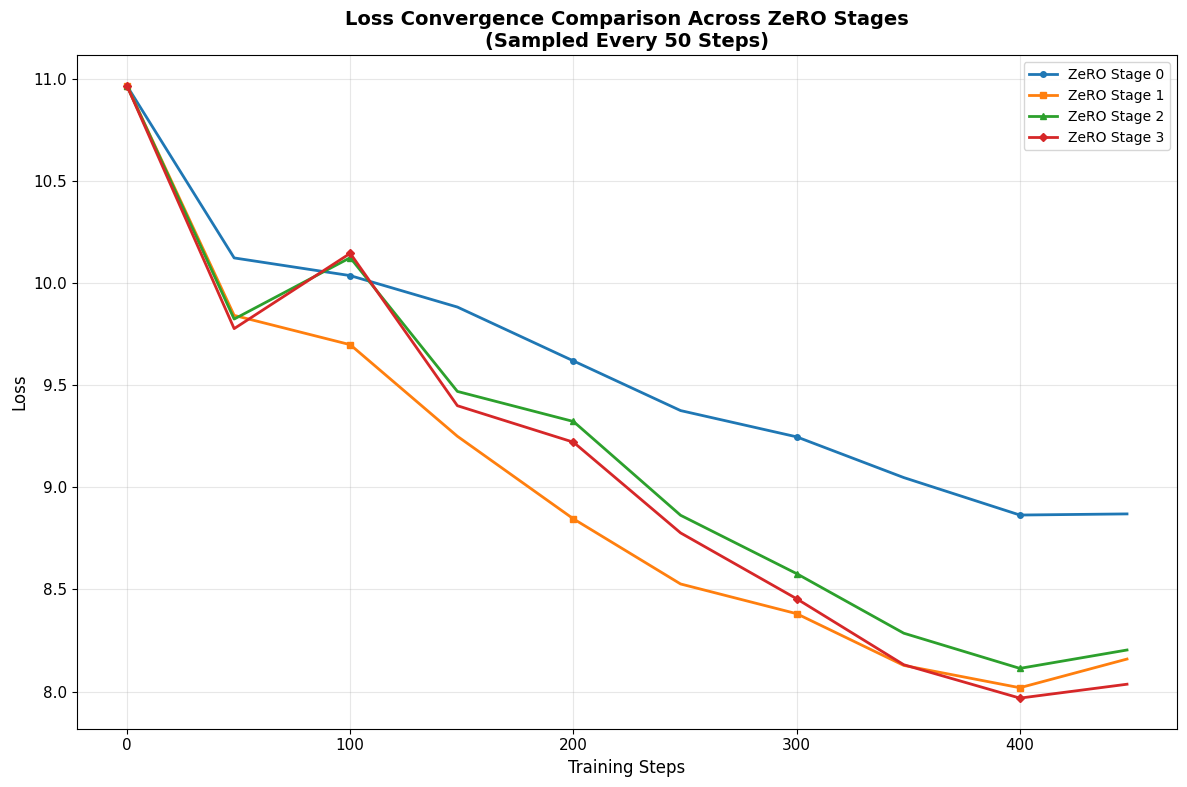

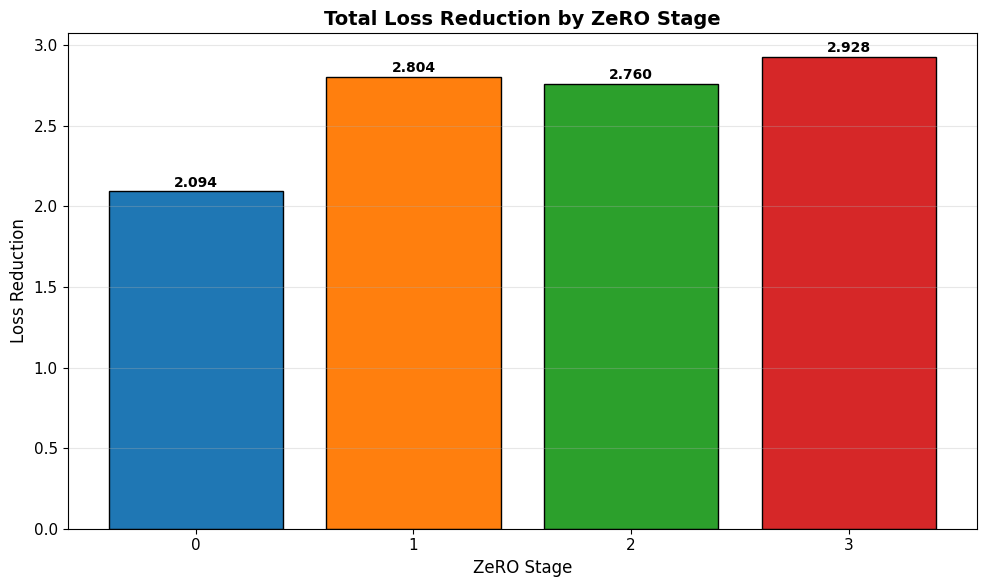

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# CONFIGURATION
# ============================================================================
SEQ_LEN = 512
BATCH_SIZE_PER_GPU = 16
DP_SIZE = 4
TOKENS_PER_STEP = BATCH_SIZE_PER_GPU * DP_SIZE * SEQ_LEN
LOSS_LOG_INTERVAL = 50  # Log loss every 50 steps

print(f"Configuration:")
print(f"  Sequence Length: {SEQ_LEN}")
print(f"  Batch Size per GPU: {BATCH_SIZE_PER_GPU}")
print(f"  Data Parallel Size: {DP_SIZE}")
print(f"  Tokens per Step: {TOKENS_PER_STEP}")
print(f"  Loss Log Interval: {LOSS_LOG_INTERVAL} steps\n")

# ============================================================================
# LOAD DATA
# ============================================================================
json_files = {
    0: "../results/stage_0_metrics.json",
    1: "../results/stage_1_metrics.json",
    2: "../results/stage_2_metrics.json",
    3: "../results/stage_3_metrics.json"
}

# Load all stage metrics
all_metrics = []
for i in range(0, 4):
    try:
        df_temp = pd.read_json(json_files[i])
        df_temp['stage'] = i
        all_metrics.append(df_temp)
        print(f"Loaded stage {i}: {len(df_temp)} records")
    except Exception as e:
        print(f"Error loading stage {i}: {e}")
        all_metrics.append(pd.DataFrame())

df_all = pd.concat(all_metrics, ignore_index=True)

# ============================================================================
# LOSS VS STEP TABLE (Every 50 Steps)
# ============================================================================
def sample_loss_at_intervals(df, stage_id, interval=50):
    """Sample loss at regular step intervals"""
    if 'loss' not in df.columns or df.empty:
        return pd.DataFrame(columns=['stage', 'step', 'loss'])
    
    stage_df = df[df['stage'] == stage_id].copy()
    
    if stage_df.empty:
        return pd.DataFrame(columns=['stage', 'step', 'loss'])
    
    stage_df = stage_df.sort_values('step')
    
    # Get steps at regular intervals
    max_step = stage_df['step'].max()
    sampled_steps = list(range(0, max_step + 1, interval))
    
    # Sample loss at each interval
    sampled_data = []
    for step in sampled_steps:
        closest_idx = (stage_df['step'] - step).abs().idxmin()
        closest_row = stage_df.loc[closest_idx]
        
        sampled_data.append({
            'stage': stage_id,
            'step': closest_row['step'],
            'loss': closest_row['loss']
        })
    
    return pd.DataFrame(sampled_data)

# Create loss table for all stages
loss_tables = []
for stage_id in range(4):
    loss_df = sample_loss_at_intervals(df_all, stage_id, LOSS_LOG_INTERVAL)
    if not loss_df.empty:
        loss_tables.append(loss_df)
        print(f"\nStage {stage_id} - Loss samples: {len(loss_df)} records")

# Create combined loss table
if loss_tables:
    # Initialize with first stage
    combined_loss = loss_tables[0][['step', 'loss']].copy()
    combined_loss = combined_loss.rename(columns={'loss': f'loss_stage_{int(loss_tables[0]["stage"].iloc[0])}'})
    
    # Add remaining stages
    for loss_df in loss_tables[1:]:
        stage = int(loss_df["stage"].iloc[0])
        temp_df = loss_df[['step', 'loss']].copy()
        temp_df = temp_df.rename(columns={'loss': f'loss_stage_{stage}'})
        combined_loss = pd.merge(combined_loss, temp_df, on='step', how='outer')
    
    # Sort by step and fill missing values
    combined_loss = combined_loss.sort_values('step').reset_index(drop=True)
    
    # Forward fill missing values (if a stage doesn't have loss at exact step)
    combined_loss = combined_loss.fillna(method='ffill')
    
    # ============================================================================
    # PRINT TABLE 0: Loss Convergence Comparison
    # ============================================================================
    print("\n" + "="*120)
    print("TABLE 0: Loss Convergence Comparison (Every 50 Steps)")
    print("="*120)
    print(combined_loss.round(4).to_string(index=False))
    
    # Save to CSV
    combined_loss.to_csv("table0_loss_convergence.csv", index=False)
    print("\n✓ Loss table saved to 'table0_loss_convergence.csv'")
    
    # ============================================================================
    # ADDITIONAL LOSS METRICS TABLE
    # ============================================================================
    print("\n" + "="*120)
    print("TABLE 0a: Loss Convergence Metrics")
    print("="*120)
    
    convergence_data = []
    for stage_id in range(4):
        stage_loss_df = loss_tables[stage_id] if stage_id < len(loss_tables) else pd.DataFrame()
        if not stage_loss_df.empty:
            initial_loss = stage_loss_df['loss'].iloc[0]
            final_loss = stage_loss_df['loss'].iloc[-1]
            loss_reduction = initial_loss - final_loss
            loss_reduction_pct = (loss_reduction / initial_loss) * 100
            
            # Calculate steps to reach 90% of final loss
            target_loss = initial_loss - 0.9 * loss_reduction
            steps_to_90 = None
            for idx, row in stage_loss_df.iterrows():
                if row['loss'] <= target_loss:
                    steps_to_90 = row['step']
                    break
            
            convergence_data.append({
                'ZeRO Stage': stage_id,
                'Initial Loss': round(initial_loss, 4),
                'Final Loss': round(final_loss, 4),
                'Loss Reduction': round(loss_reduction, 4),
                'Reduction %': round(loss_reduction_pct, 2),
                'Steps to 90% Conv': steps_to_90 if steps_to_90 else 'N/A'
            })
    
    convergence_df = pd.DataFrame(convergence_data)
    print(convergence_df.to_string(index=False))
    convergence_df.to_csv("table0_loss_convergence_metrics.csv", index=False)
    
    # ============================================================================
    # PLOT LOSS CURVES
    # ============================================================================
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']
    
    for idx, loss_df in enumerate(loss_tables):
        stage = int(loss_df['stage'].iloc[0])
        plt.plot(loss_df['step'], loss_df['loss'], 
                marker=markers[idx % len(markers)], 
                markersize=4,
                linewidth=2, 
                label=f'ZeRO Stage {stage}',
                color=colors[idx % len(colors)],
                markevery=2)
    
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss Convergence Comparison Across ZeRO Stages\n(Sampled Every 50 Steps)', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('00_loss_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Plot loss reduction bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(convergence_df['ZeRO Stage'], convergence_df['Loss Reduction'], 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
                  edgecolor='black')
    plt.xlabel('ZeRO Stage', fontsize=12)
    plt.ylabel('Loss Reduction', fontsize=12)
    plt.title('Total Loss Reduction by ZeRO Stage', fontsize=14, fontweight='bold')
    plt.xticks(convergence_df['ZeRO Stage'])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, convergence_df['Loss Reduction']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('00_loss_reduction.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("\n⚠️ No loss data available in the JSON files")
    print("Make sure your JSON files contain a 'loss' column")

✓ Loaded 16 perplexity entries for Stage 0
✓ Loaded 16 perplexity entries for Stage 1
✓ Loaded 17 perplexity entries for Stage 2
✓ Loaded 16 perplexity entries for Stage 3

Total loaded: 65 entries
   stage  step  perplexity      checkpoint
0      0   128  20005.9102  global_step128
1      0   160  17503.9651  global_step160
2      0   192  15286.0029  global_step192
3      0   224  13181.5617  global_step224
4      0   256  11397.6734  global_step256


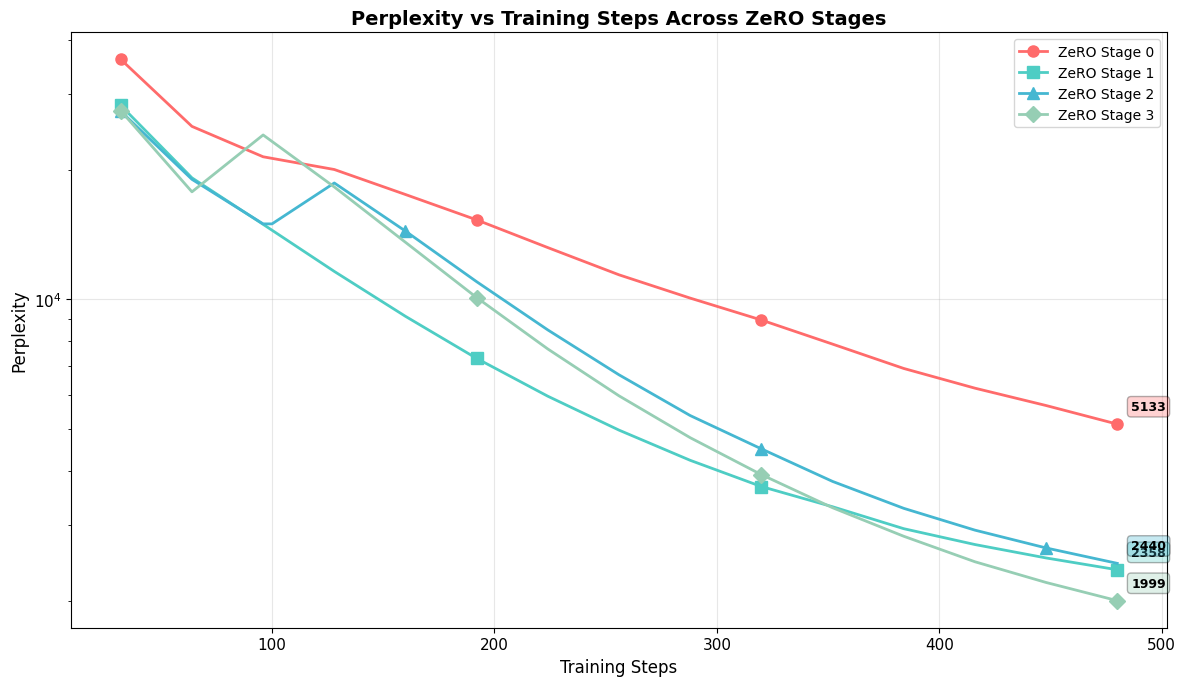

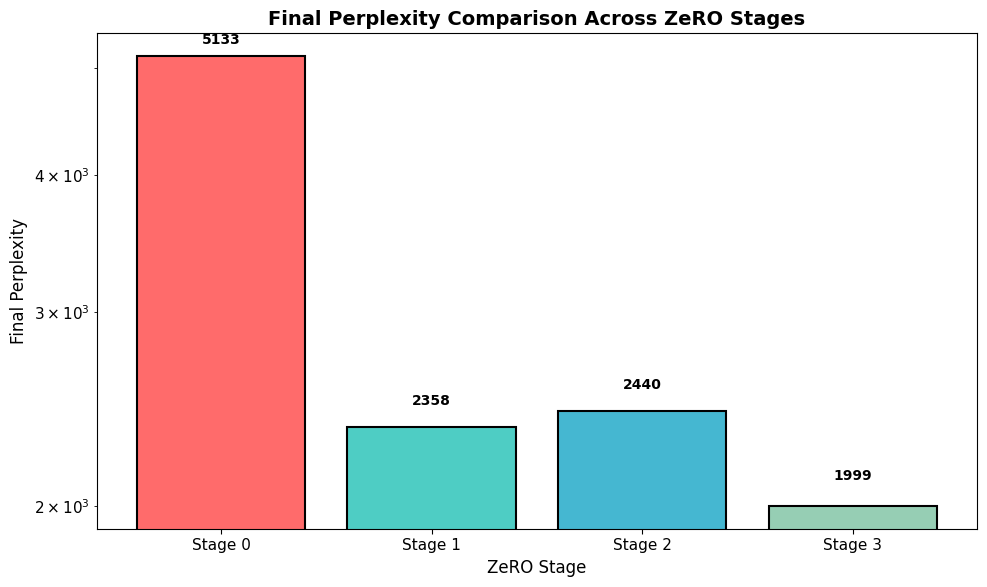

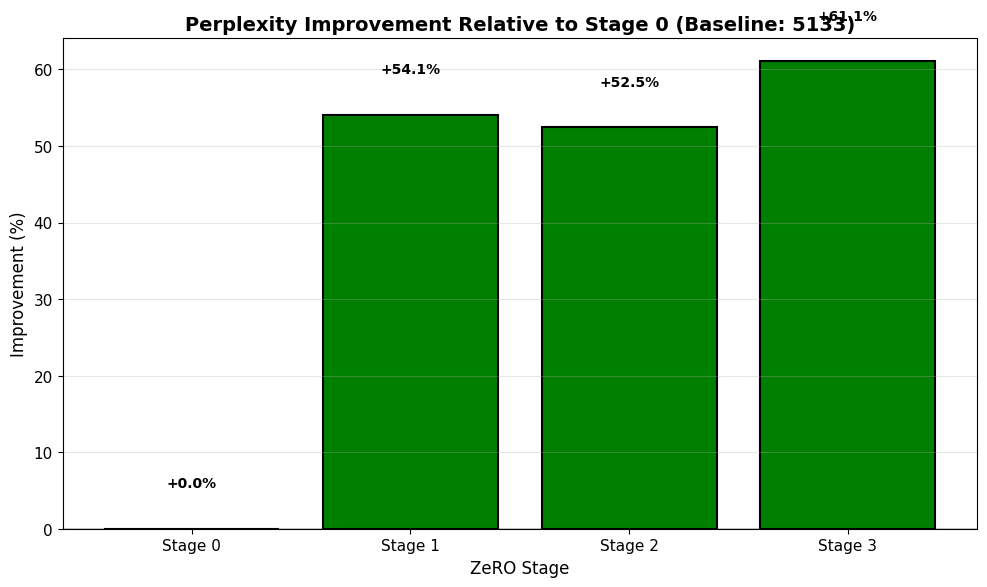

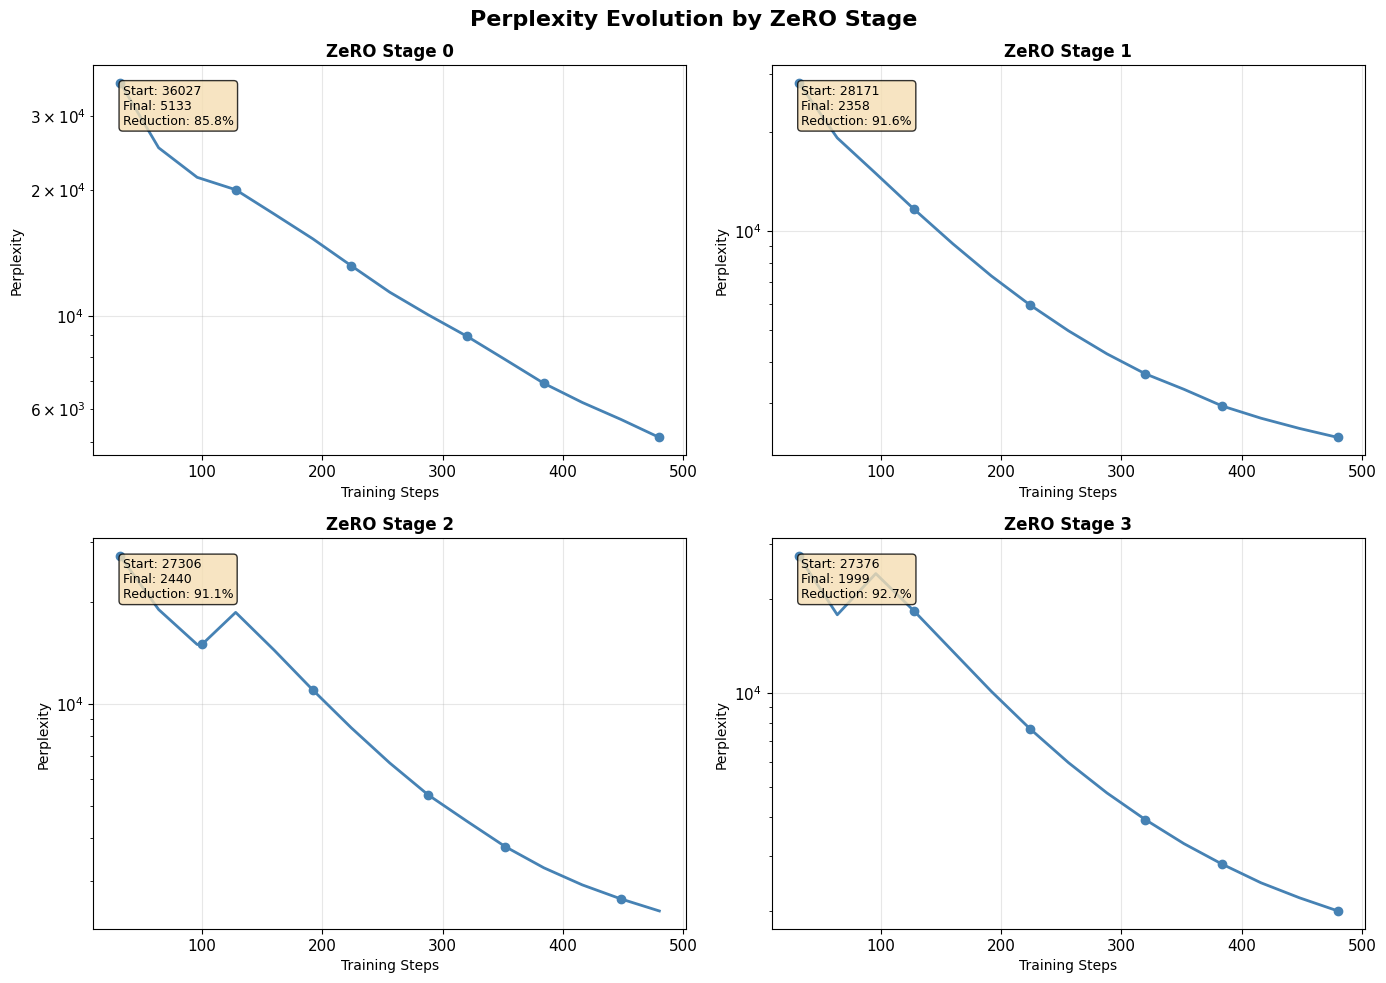

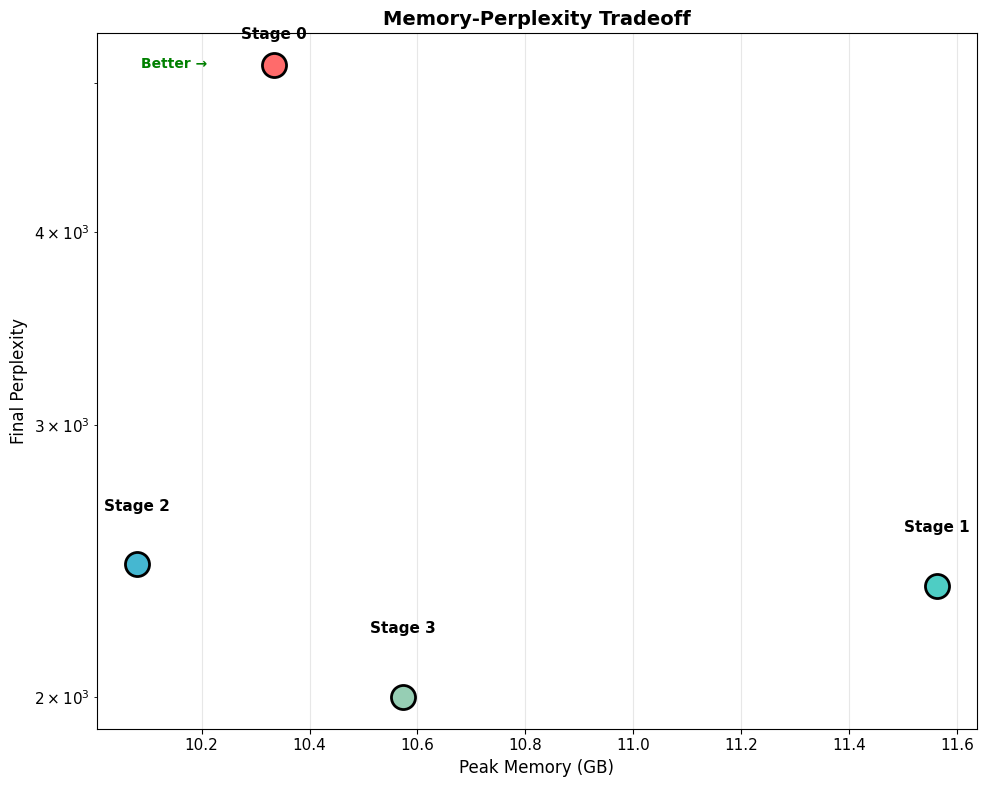


PERPLEXITY RESULTS SUMMARY
 Stage Initial Perplexity Final Perplexity Improvement  Checkpoints
     0              36027             5133       85.8%           16
     1              28171             2358       91.6%           16
     2              27306             2440       91.1%           17
     3              27376             1999       92.7%           16

BEST PERFORMING CONFIGURATION

Best Final Perplexity: ZeRO Stage 3
  Final Perplexity: 1999
  Improvement from start: 92.7%

Best Improvement Rate: ZeRO Stage 3
  Improvement: 92.7%
  Final Perplexity: 1999


In [28]:
# ============================================================================
# LOAD PERPLEXITY RESULTS FROM ALL STAGES
# ============================================================================

def load_perplexity_results(stage_paths):
    """
    Load perplexity results from JSON files for different ZeRO stages.
    
    Args:
        stage_paths: dict {stage_id: file_path}
    
    Returns:
        DataFrame with columns: stage, step, perplexity
    """
    all_data = []
    
    for stage_id, file_path in stage_paths.items():
        if Path(file_path).exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            for item in data:
                # Extract step number from checkpoint name (e.g., "global_step128")
                step = int(item['checkpoint'].split('_')[-1].replace("step",''))
                
                all_data.append({
                    'stage': stage_id,
                    'step': step,
                    'perplexity': item['perplexity'],
                    'checkpoint': item['checkpoint']
                })
            
            print(f"✓ Loaded {len(data)} perplexity entries for Stage {stage_id}")
        else:
            print(f"✗ File not found: {file_path}")
    
    df = pd.DataFrame(all_data)
    return df

# Define file paths
perplexity_files = {
    0: "../outputs/stage_0/perplexity_results.json",
    1: "../outputs/stage_1/perplexity_results.json",
    2: "../outputs/stage_2/perplexity_results.json",
    3: "../outputs/stage_3/perplexity_results.json"
}

# Load data
df_perplexity = load_perplexity_results(perplexity_files)

print(f"\nTotal loaded: {len(df_perplexity)} entries")
print(df_perplexity.head())

# ============================================================================
# PLOT 1: PERPLEXITY OVER TRAINING STEPS (LINE PLOT)
# ============================================================================
plt.figure(figsize=(12, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
markers = ['o', 's', '^', 'D']

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    plt.plot(stage_data['step'], stage_data['perplexity'], 
             marker=markers[idx], markersize=8, linewidth=2,
             label=f'ZeRO Stage {stage}', color=colors[idx], markevery=5)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)
plt.title('Perplexity vs Training Steps Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Perplexity typically improves exponentially, log scale helps visualization

# Add annotations for best perplexity at final step
for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_step = stage_data['step'].iloc[-1]
        final_ppl = stage_data['perplexity'].iloc[-1]
        plt.annotate(f'{final_ppl:.0f}', 
                    xy=(final_step, final_ppl),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx], alpha=0.3))

plt.tight_layout()
plt.savefig('perplexity_over_steps.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 2: PERPLEXITY BAR CHART (FINAL CHECKPOINT COMPARISON)
# ============================================================================
plt.figure(figsize=(10, 6))

# Get final perplexity for each stage
final_ppl = []
stages = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_ppl.append(stage_data['perplexity'].iloc[-1])
        stages.append(stage)

bars = plt.bar([f'Stage {s}' for s in stages], final_ppl, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(stages)],
               edgecolor='black', linewidth=1.5)

plt.xlabel('ZeRO Stage', fontsize=12)
plt.ylabel('Final Perplexity', fontsize=12)
plt.title('Final Perplexity Comparison Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, final_ppl):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('final_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 3: PERPLEXITY IMPROVEMENT RELATIVE TO STAGE 0
# ============================================================================
plt.figure(figsize=(10, 6))

# Get baseline (Stage 0 final perplexity)
stage0_data = df_perplexity[df_perplexity['stage'] == 0].sort_values('step')
if not stage0_data.empty:
    baseline_ppl = stage0_data['perplexity'].iloc[-1]
    
    improvements = []
    stages = []
    for stage in sorted(df_perplexity['stage'].unique()):
        stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
        if not stage_data.empty:
            final_ppl = stage_data['perplexity'].iloc[-1]
            improvement = (baseline_ppl - final_ppl) / baseline_ppl * 100
            improvements.append(improvement)
            stages.append(stage)
    
    colors_bar = ['red' if imp < 0 else 'green' for imp in improvements]
    bars = plt.bar([f'Stage {s}' for s in stages], improvements, 
                   color=colors_bar, edgecolor='black', linewidth=1.5)
    
    plt.xlabel('ZeRO Stage', fontsize=12)
    plt.ylabel('Improvement (%)', fontsize=12)
    plt.title(f'Perplexity Improvement Relative to Stage 0 (Baseline: {baseline_ppl:.0f})', 
              fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, imp in zip(bars, improvements):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if imp >= 0 else -15), 
                 f'{imp:+.1f}%', ha='center', va='bottom' if imp >= 0 else 'top', 
                 fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('perplexity_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# PLOT 4: SUBPLOT GRID WITH ALL STAGES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perplexity Evolution by ZeRO Stage', fontsize=16, fontweight='bold')

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    ax = axes[idx // 2, idx % 2]
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    
    ax.plot(stage_data['step'], stage_data['perplexity'], 
            marker='o', markersize=6, linewidth=2, color='steelblue', markevery=3)
    ax.set_xlabel('Training Steps', fontsize=10)
    ax.set_ylabel('Perplexity', fontsize=10)
    ax.set_title(f'ZeRO Stage {stage}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Add annotations for key points
    first_ppl = stage_data['perplexity'].iloc[0]
    final_ppl = stage_data['perplexity'].iloc[-1]
    reduction = (first_ppl - final_ppl) / first_ppl * 100
    
    ax.text(0.05, 0.95, f'Start: {first_ppl:.0f}\nFinal: {final_ppl:.0f}\nReduction: {reduction:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.savefig('perplexity_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 5: PERPLEXITY vs GPU MEMORY (Tradeoff Analysis)
# ============================================================================
# Merge with memory data from your training metrics
# If you have memory data from training, you can create this plot

# Example: Assuming you have a summary DataFrame with memory usage
# If not, you can skip this plot or add dummy data

try:
    # If you have df_all from previous analysis
    if 'df_all' in globals():
        memory_by_stage = df_all.groupby('stage')['peak_gb'].mean().reset_index()
        perplexity_by_stage = df_perplexity.groupby('stage').agg({
            'perplexity': 'last'
        }).reset_index()
        
        merged = pd.merge(memory_by_stage, perplexity_by_stage, on='stage')
        
        plt.figure(figsize=(10, 8))
        for _, row in merged.iterrows():
            plt.scatter(row['peak_gb'], row['perplexity'], s=300, 
                       c=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][int(row['stage'])],
                       edgecolor='black', linewidth=2)
            plt.text(row['peak_gb'], row['perplexity'] + 200, f"Stage {int(row['stage'])}", 
                    ha='center', fontweight='bold', fontsize=11)
        
        plt.xlabel('Peak Memory (GB)', fontsize=12)
        plt.ylabel('Final Perplexity', fontsize=12)
        plt.title('Memory-Perplexity Tradeoff', fontsize=14, fontweight='bold')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        # Add arrow to show tradeoff direction
        plt.annotate('Better →', xy=(merged['peak_gb'].min(), merged['perplexity'].min()), 
                    xytext=(0.05, 0.95), textcoords='axes fraction',
                    fontsize=10, fontweight='bold', color='green')
        
        plt.tight_layout()
        plt.savefig('memory_perplexity_tradeoff.png', dpi=150, bbox_inches='tight')
        plt.show()
except NameError:
    print("Skipping memory-perplexity tradeoff plot (df_all not available)")

# ============================================================================
# PRINT SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("PERPLEXITY RESULTS SUMMARY")
print("="*80)

summary_data = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        first_ppl = stage_data['perplexity'].iloc[0]
        final_ppl = stage_data['perplexity'].iloc[-1]
        improvement = (first_ppl - final_ppl) / first_ppl * 100
        
        summary_data.append({
            'Stage': stage,
            'Initial Perplexity': f'{first_ppl:.0f}',
            'Final Perplexity': f'{final_ppl:.0f}',
            'Improvement': f'{improvement:.1f}%',
            'Checkpoints': len(stage_data)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================================
# BEST PERFORMING STAGE
# ============================================================================
print("\n" + "="*80)
print("BEST PERFORMING CONFIGURATION")
print("="*80)

best_stage_row = summary_df.loc[summary_df['Final Perplexity'].astype(float).idxmin()]
print(f"\nBest Final Perplexity: ZeRO Stage {best_stage_row['Stage'].values[0] if hasattr(best_stage_row['Stage'], 'values') else best_stage_row['Stage']}")
print(f"  Final Perplexity: {best_stage_row['Final Perplexity']}")
print(f"  Improvement from start: {best_stage_row['Improvement']}")

# Calculate which stage improved most
best_improvement_row = summary_df.loc[summary_df['Improvement'].str.rstrip('%').astype(float).idxmax()]
print(f"\nBest Improvement Rate: ZeRO Stage {best_improvement_row['Stage'].values[0] if hasattr(best_improvement_row['Stage'], 'values') else best_improvement_row['Stage']}")
print(f"  Improvement: {best_improvement_row['Improvement']}")
print(f"  Final Perplexity: {best_improvement_row['Final Perplexity']}")


In [29]:
def analyze_response_quality(df_perplexity, stage=0):
    """
    Optional function to analyze sample response quality from checkpoints
    """
    import json
    
    file_path = perplexity_files.get(stage)
    if file_path and Path(file_path).exists():
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        print(f"\n" + "="*80)
        print(f"SAMPLE RESPONSES - ZeRO Stage {stage}")
        print("="*80)
        
        for item in data[:3]:  # Show first 3 checkpoints
            print(f"\nCheckpoint: {item['checkpoint']}")
            print(f"Perplexity: {item['perplexity']:.0f}")
            print(f"Prompt: {item['sample']['prompt']}")
            print(f"Response: {item['sample']['response'][:150]}...")
            print("-" * 40)

# Sample responses
for stage in [0, 1, 2, 3]:
    analyze_response_quality(df_perplexity, stage)


SAMPLE RESPONSES - ZeRO Stage 0

Checkpoint: global_step128
Perplexity: 20006
Prompt: Once upon a time
Response: Once upon a time, the
 the-
 NK, learning a towardist,, thanksFX insights
,

 SauTool
 Emmanuel :
, the.
Sa thanks tomorrow


 group
 DickensSa | the ...
----------------------------------------

Checkpoint: global_step160
Perplexity: 17504
Prompt: Once upon a time
Response: Once upon a time, the IT the-
 the, learning a andist Deus,,W, common,

 Sau, under the her
,..
,,, JD
 under group
unknown | |� toward2. of,
 prevent...
----------------------------------------

Checkpoint: global_step192
Perplexity: 15286
Prompt: Once upon a time
Response: Once upon a time, the message the-
,, learning a andist,,, Ther, common,

 the, under the her,,.,,,,,,, under not,, common,,, candidates, of,
 learnin...
----------------------------------------

SAMPLE RESPONSES - ZeRO Stage 1

Checkpoint: global_step128
Perplexity: 11607
Prompt: Once upon a time
Response: Once upon a time, the no 

In [30]:
import pandas as pd

data = [
    ["0-480", 0, 125829120, 1136.74, 456.28, 1593.02],
    ["0-480", 1, 125829120, 1200.71, 439.22, 1639.93],
    ["0-480", 2, 125829120, 2762.33, 435.02, 3197.35],
    ["0-480", 3, 125829120, 2226.325, 460.75, 2687.075],
]

columns = [
    "steps",
    "stage",
    "token_processed",
    "train_time",
    "inference_time",
    "total_time"
]

df = pd.DataFrame(data, columns=columns)
df["throughput_tokens_per_sec"] = df["token_processed"] / df["train_time"]
df

,steps,stage,token_processed,train_time,inference_time,total_time,throughput_tokens_per_sec
0,0-480,0,125829120,1136.740,456.28,1593.020,110692.964090
1,0-480,1,125829120,1200.710,439.22,1639.930,104795.595939
2,0-480,2,125829120,2762.330,435.02,3197.350,45551.805903
3,0-480,3,125829120,2226.325,460.75,2687.075,56518.756246
